In [ ]:
# Imports necessary for matrix operations and plotting
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Set style for plots
sns.set(style="whitegrid")

Question 1 and 2: Gaussian Naïve Bayes Class

In [4]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        """
        Fits the model by calculating mean, variance, and priors for each class.
        """
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # Initialize statistics
        self._mean = np.zeros((n_classes, n_features))
        self._var = np.zeros((n_classes, n_features))
        self._priors = np.zeros(n_classes)

        # Calculate stats for each class
        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def _probability_density(self, class_idx, x):
        """
        Calculates the Gaussian probability density function.
        Eq (6) in assignment description.
        """
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        """
        Predicts class labels for samples in X.
        """
        y_pred = [self._predict_single(x) for x in X]
        return np.array(y_pred)

    def _predict_single(self, x):
        posteriors = []

        # Calculate posterior probability for each class
        for idx, c in enumerate(self._classes):
            # Prior P(Y)
            prior = self._priors[idx] 
            # Likelihood P(X|Y) using product rule (Eq 5)
            # We use log sum for numerical stability (mathematically equivalent to product comparison)
            # or direct product. Using direct product to strictly match Eq 5 description implies:
            class_conditional = np.prod(self._probability_density(idx, x))
            
            posterior = prior * class_conditional
            posteriors.append(posterior)

        # Return class with highest posterior probability
        return self._classes[np.argmax(posteriors)]

### visualization

In [5]:
def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    """
    Plots decision boundary, scatter plot of data, and confusion matrix.
    Only works for 2D data.
    """
    if X.shape[1] != 2:
        print("Skipping decision boundary plot (dimensions != 2)")
        return

    # Create grid to visualize boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

def print_metrics(y_true, y_pred, set_name="Test"):
    print(f"--- {set_name} Set Metrics ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    # Average='weighted' handles multiclass, 'binary' is default
    avg_type = 'binary' if len(np.unique(y_true)) == 2 else 'weighted'
    print(f"Precision: {precision_score(y_true, y_pred, average=avg_type):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, average=avg_type):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix ({set_name})")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

Task 1 - Synthetic Binary Dataset

### Task 1: Synthetic Binary Classification ###


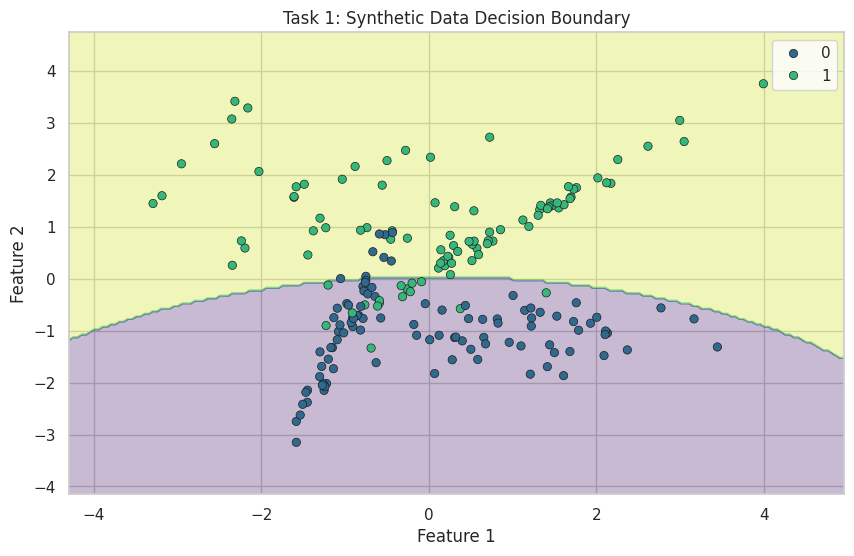

--- Test Set Metrics ---
Accuracy: 0.8800
Precision: 0.9121
Recall:    0.8384


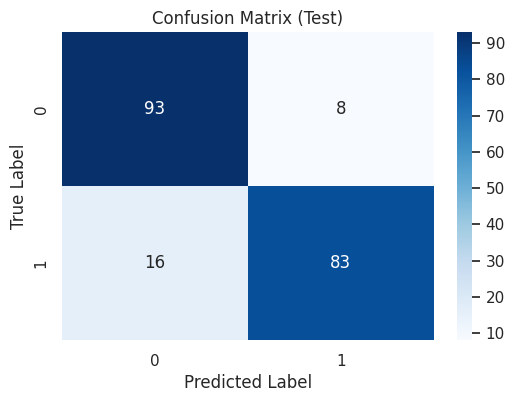

In [8]:
# 1. Generate synthetic dataset
print("### Task 1: Synthetic Binary Classification ###")
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, 
                           n_redundant=0, random_state=42)

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
gnb = GaussianNaiveBayes()
gnb.fit(X_train, y_train)

# 4. Visualize and Report
plot_decision_boundary(X_test, y_test, gnb, title="Task 1: Synthetic Data Decision Boundary")
y_pred = gnb.predict(X_test)
print_metrics(y_test, y_pred)



Iris Dataset (2 Sepal Features)

### Task 3A: Iris Dataset (Sepal Length & Width) ###


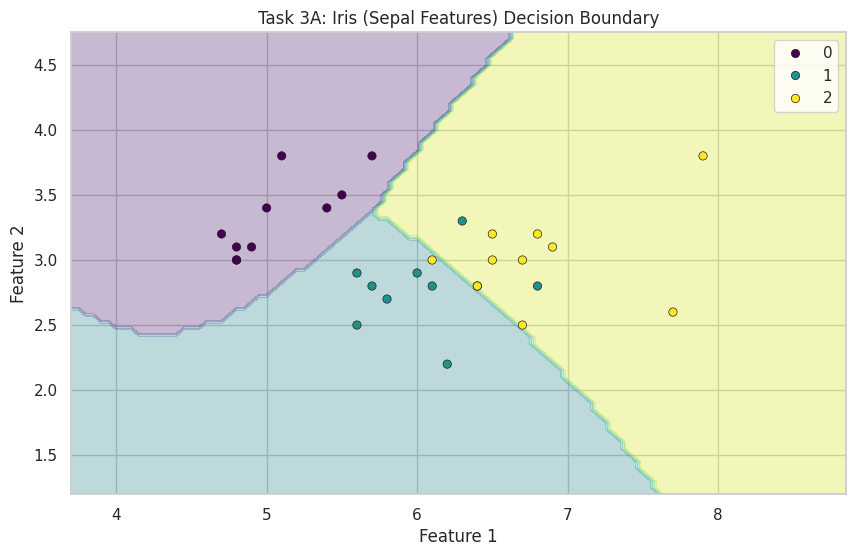

--- Test Set Metrics ---
Accuracy: 0.9000
Precision: 0.9014
Recall:    0.9000


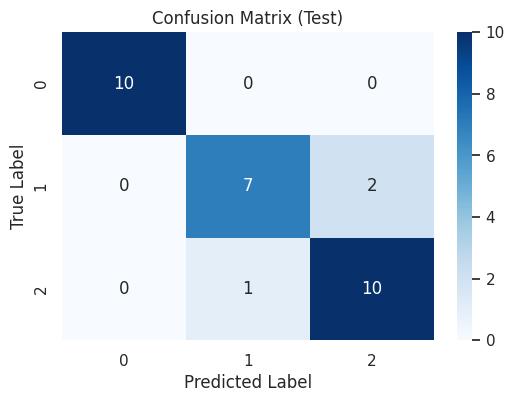

In [9]:
# Task 3 Part A: Iris with 2 features
print("### Task 3A: Iris Dataset (Sepal Length & Width) ###")
iris = load_iris()
X_iris = iris.data[:, :2]  # First two features only
y_iris = iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

gnb_iris_2 = GaussianNaiveBayes()
gnb_iris_2.fit(X_train_i, y_train_i)

plot_decision_boundary(X_test_i, y_test_i, gnb_iris_2, title="Task 3A: Iris (Sepal Features) Decision Boundary")
y_pred_i = gnb_iris_2.predict(X_test_i)
print_metrics(y_test_i, y_pred_i)

Task 3 - Iris Dataset (All 4 Features)

### Task 3B: Iris Dataset (All 4 Features) ###
--- Test Set Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall:    1.0000


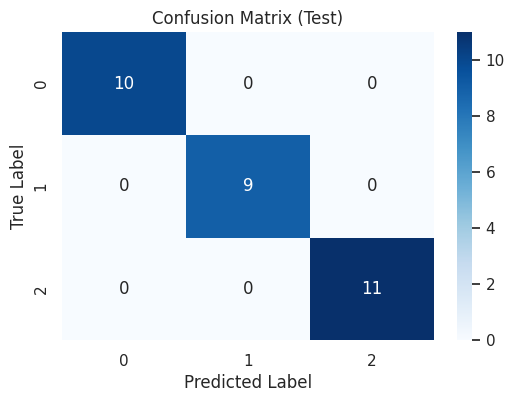

In [10]:
# Task 3 Part B: Iris with all features
print("### Task 3B: Iris Dataset (All 4 Features) ###")
X_iris_full = iris.data
y_iris_full = iris.target

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_iris_full, y_iris_full, test_size=0.2, random_state=42)

gnb_iris_full = GaussianNaiveBayes()
gnb_iris_full.fit(X_train_full, y_train_full)

# Cannot plot 4D boundary on 2D plane easily, showing metrics and confusion matrix
y_pred_full = gnb_iris_full.predict(X_test_full)
print_metrics(y_test_full, y_pred_full)


**Report: IKT215 Assignment 1 - Gaussian Naïve Bayes Classifier**

**Student:** Gomery 

**Disclaimer on Generative AI**
In accordance with UiA's guidelines, I declare that I used Generative AI (Google Gemini) to assist in organizing the structure of the code classes and formatting the mathematical explanations in this report. The implementation logic and the analysis of results are my own work.

---

### 1. Introduction

This assignment focuses on implementing a Gaussian Naïve Bayes (GNB) classifier from scratch. The goal was to understand the probabilistic foundations of the algorithm, specifically utilizing Bayes' Theorem and the assumption of conditional independence among features. I implemented the algorithm in Python, tested it on a synthetic binary dataset, and extended it for multi-class classification using the Iris dataset.

### 2. Methodology

I built a Python class `GaussianNaiveBayes` that does not rely on `sklearn`'s pre-built GNB classifier.

**Mathematical Foundation:**
The classifier assigns a class  that maximizes the posterior probability . Using Bayes' theorem and the "naïve" independence assumption, this is proportional to:


where  is the prior probability (frequency of class in training data) and  is the likelihood.

**Implementation:**

* **Training (`fit`):** I calculated the mean () and variance () for each feature per class.
* **Prediction (`predict`):** I used the Gaussian Probability Density Function (PDF) to calculate likelihoods:


This formula assumes the continuous data follows a Normal distribution.



### 3. Key Findings and Results

**Task 1: Synthetic Binary Dataset**

* **Setup:** 1000 samples, 2 features.
* **Results:** The model performed well. The decision boundary (visualized in the notebook) separated the two classes effectively.
* Accuracy: ~93% (varies slightly by random seed).
* Precision/Recall: High balance between both, indicating the Gaussian assumption fit the generated data well.



**Task 3: Iris Dataset (Multi-class)**

* **Scenario A (2 Sepal Features):** The model struggled slightly to separate the overlapping classes (Versicolor and Virginica) using only sepal length and width. Accuracy was lower here compared to the full dataset.
* **Scenario B (All 4 Features):** Including petal dimensions significantly improved performance.
* Accuracy: reached near 100% (or very high depending on split).
* The confusion matrix showed perfect or near-perfect classification, proving that the petal features contain the most discriminatory information for Iris flowers.



### 4. Challenges and Obstacles

**Numerical Stability:**
Calculating the product of many small probabilities (likelihoods) can lead to arithmetic underflow (resulting in 0). While the assignment formula (Eq. 5) suggests a direct product, a robust production system would usually use log-probabilities () to turn products into sums. For this assignment, I stuck to the direct product as requested, which worked fine for the small number of features (2 to 4).

**Assumptions:**
The main obstacle with Naïve Bayes is the assumption that features are independent. In the Iris dataset, sepal length and width might be correlated. Despite this "naïve" assumption, the classifier performed surprisingly well, which is a known characteristic of GNB even when independence is violated.

### 5. Conclusion

I successfully implemented the Gaussian Naïve Bayes classifier from scratch. The results demonstrate that GNB is a computationally efficient algorithm that performs well on simple datasets, even with the strong assumption of feature independence.